In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/cnnfnn/pytorch/cnnfnnmnist/1/model_weights.pth
/kaggle/input/dog-vs-cat/Data/test/7981.jpg
/kaggle/input/dog-vs-cat/Data/test/6234.jpg
/kaggle/input/dog-vs-cat/Data/test/1269.jpg
/kaggle/input/dog-vs-cat/Data/test/3863.jpg
/kaggle/input/dog-vs-cat/Data/test/6241.jpg
/kaggle/input/dog-vs-cat/Data/test/10304.jpg
/kaggle/input/dog-vs-cat/Data/test/623.jpg
/kaggle/input/dog-vs-cat/Data/test/2193.jpg
/kaggle/input/dog-vs-cat/Data/test/11925.jpg
/kaggle/input/dog-vs-cat/Data/test/3750.jpg
/kaggle/input/dog-vs-cat/Data/test/11378.jpg
/kaggle/input/dog-vs-cat/Data/test/2008.jpg
/kaggle/input/dog-vs-cat/Data/test/10730.jpg
/kaggle/input/dog-vs-cat/Data/test/5982.jpg
/kaggle/input/dog-vs-cat/Data/test/7737.jpg
/kaggle/input/dog-vs-cat/Data/test/2081.jpg
/kaggle/input/dog-vs-cat/Data/test/10597.jpg
/kaggle/input/dog-vs-cat/Data/test/6588.jpg
/kaggle/input/dog-vs-cat/Data/test/10054.jpg
/kaggle/input/dog-vs-cat/Data/test/7966.jpg
/kaggle/input/dog-vs-cat/Data/test/3919.jpg
/kaggle/in

In [2]:
import torch
from torch import nn
from torch.utils.data import Dataset,random_split
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import os
from PIL import Image

class DogCatDataset(Dataset):
    def __init__(self, data_dir, data_type='train', transform=None):
        
        self.data_dir = os.path.join(data_dir, data_type)
        self.transform = transform
        self.images = []
        self.labels = []

        for filename in os.listdir(self.data_dir):
            if filename.startswith('cat'):
                self.labels.append(0)  
            elif filename.startswith('dog'):
                self.labels.append(1)  
            self.images.append(os.path.join(self.data_dir, filename))

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        image_path = self.images[idx]
        image = Image.open(image_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label

transform = transforms.Compose([
        transforms.Resize((256, 256)),
        transforms.ToTensor(),
    ])
dataset = DogCatDataset(data_dir='/kaggle/input/dog-vs-cat/Data', data_type='train', transform=transform)
training_data, val_data = random_split(dataset, [20000, 5000])

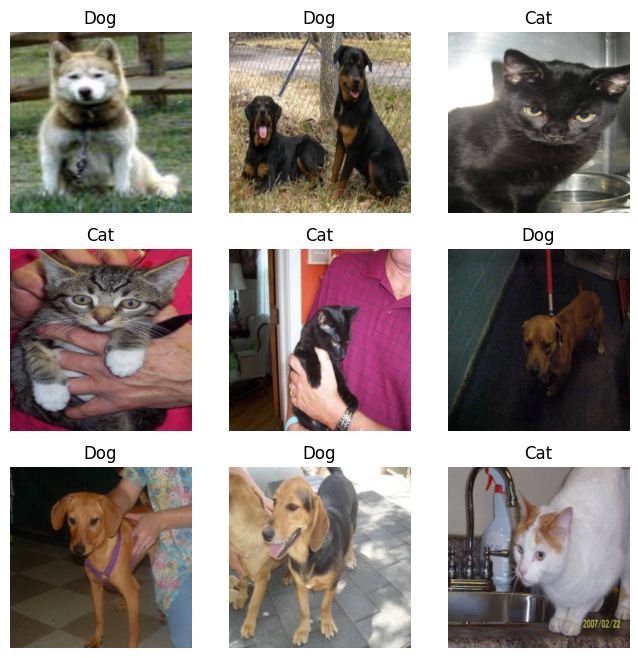

In [3]:
labels_map = {
    0: "Cat",
    1: "Dog"
}
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    img=img.permute(1,2,0)
    figure.add_subplot(rows, cols, i)
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img)
plt.show()

In [4]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_relu_stack=nn.Sequential(
            nn.BatchNorm2d(1),
            nn.Conv2d(1,64,3,1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.Conv2d(64,64,3,1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.BatchNorm2d(64),
            nn.Conv2d(64,128,3,1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.Conv2d(128,128,3,1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.BatchNorm2d(128),
            nn.Flatten(),
            nn.Linear(2048,512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Linear(512,256),
            nn.ReLU(),
            nn.Linear(256,10)
        )
    def forward(self,X):
        logits=self.linear_relu_stack(X)
        return logits

def train_loop(train_dataloader,val_dataloader,model,loss_fn,optimizer,batch_size,epoch):
    train_size=len(train_dataloader.dataset)
    num_batches=len(train_dataloader)
    loss_tot=0
    train_correct=0
    for batch,(X,y) in enumerate(train_dataloader):
        X, y = X.to(device), y.to(device)
        model.train()
        pred=model(X)
        loss=loss_fn(pred,y)
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()
        loss_tot+=loss.item()
        model.eval()
        pred=model(X)
        train_correct_each = (pred.argmax(1) == y).type(torch.float).sum().item()
        train_acc=train_correct_each/(y.shape[0])
        train_correct+=train_correct_each
        loss, current = loss.item(), batch * batch_size + len(X)
        print(f"\rEpoch {epoch+1} : Training loss: {loss:>7f} - Training Accuracy: {train_acc:>7f}  [{current:>5d}/{train_size:>5d}]", end="")
    loss_avg=loss_tot/num_batches
    train_acc = train_correct/train_size
    val_loss = 0
    val_correct=0
    val_size=len(val_dataloader.dataset)
    model.eval()
    with torch.no_grad():
        for X, y in val_dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            val_loss += loss_fn(pred, y).item()
            val_correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    val_loss /= len(val_dataloader)
    val_acc=val_correct/val_size
    print(f"\rEpoch {epoch+1} : Training loss: {loss_avg:>7f} - Training Accuracy: {train_acc:>7f} - Validation loss: {val_loss:>7f} - Validation accuracy: {val_acc:>7f}")
    print(end='')
    return loss_avg, train_acc, val_loss, val_acc


def test_loop(dataloader,model,loss_fn):
    size=len(dataloader.dataset)
    model.eval()
    num_batches=len(dataloader)
    test_loss, correct = 0, 0
    with torch.no_grad():
        for (X,y) in dataloader:
            X, y = X.to(device), y.to(device)
            pred=model(X)
            test_loss+=loss_fn(pred,y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    test_acc=correct/size
    print(f"Test Error: \n Accuracy: {(100*test_acc):>0.1f}%, Avg loss: {test_loss:>8f} \n")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model=NeuralNetwork().to(device)
learning_rate = 1e-3
batch_size = 64
epochs = 5
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

train_dataloader=DataLoader(training_data,batch_size,shuffle=True)
validation_dataloader = DataLoader(val_data, batch_size, shuffle=True)


In [5]:
loss_history = {'train': [], 'val': []}
accuracy_history = {'train': [], 'val': []}
model.linear_relu_stack[0] = nn.BatchNorm2d(3).to(device)
model.linear_relu_stack[1] = nn.Conv2d(3, 64, 3, 1).to(device)
model.linear_relu_stack[-1] = nn.Linear(256, 2).to(device)
flatten_index=-7
new_layers_before_flatten = [
        nn.Conv2d(128, 128, 3, 1),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(128, 128, 3, 1),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(128, 128, 3, 1),
        nn.ReLU(),
        nn.MaxPool2d(2),
        nn.Conv2d(128, 128, 2, 1),
        nn.ReLU(),
        nn.BatchNorm2d(128)
    ]
new_layers = list(model.linear_relu_stack[:flatten_index]) + new_layers_before_flatten + list(model.linear_relu_stack[flatten_index:])
model.linear_relu_stack = nn.Sequential(*new_layers).to(device)

print(model)
for t in range(epochs):
    print(f"Epoch {t+1}",end=" ")
    train_loss, train_accuracy, val_loss, val_accuracy =train_loop(train_dataloader,validation_dataloader, model, loss_fn, optimizer,batch_size,t)
    loss_history['train'].append(train_loss)
    loss_history['val'].append(val_loss)
    accuracy_history['train'].append(train_accuracy)
    accuracy_history['val'].append(val_accuracy)

NeuralNetwork(
  (linear_relu_stack): Sequential(
    (0): BatchNorm2d(3, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1))
    (2): ReLU()
    (3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
    (9): ReLU()
    (10): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1))
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (15): Conv2d(128, 128, ke

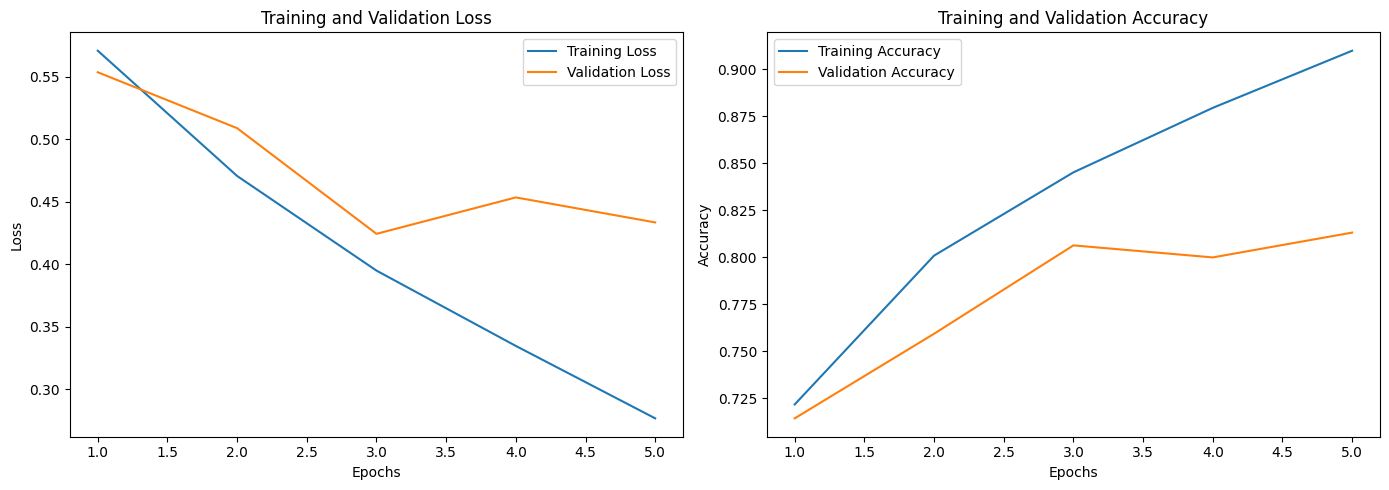

In [6]:
plt.figure(figsize=(14, 5))
eplist=[]
for i in range(epochs):
    eplist.append(i+1)
plt.subplot(1, 2, 1)
plt.plot(eplist, loss_history['train'], label='Training Loss')
plt.plot(eplist, loss_history['val'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(eplist, accuracy_history['train'], label='Training Accuracy')
plt.plot(eplist, accuracy_history['val'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [7]:
torch.save(model.state_dict(), 'model_weightsdogcat.pth')